#                      Titanic Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

In [3]:
train_df=pd.read_csv('train.csv')
test_df=pd.read_csv('test.csv')

In [4]:
train_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [5]:
train_df.shape

(891, 12)

In [6]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Checking missing values :

In [9]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

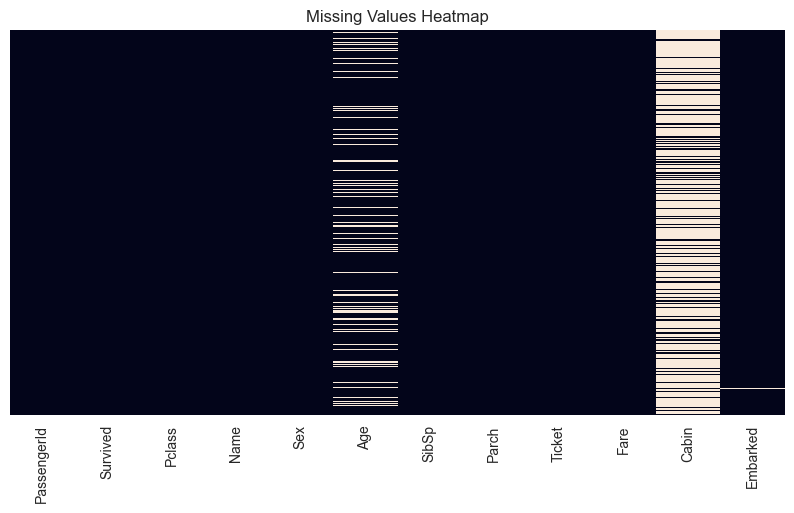

In [10]:
plt.figure(figsize=(10,5))
sns.heatmap(train_df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

## Handling missing values :

In [11]:
# Fill Missing Age with Median because it handles outliers better than Mean
train_df['Age']=train_df['Age'].fillna(train_df['Age'].median())
test_df['Age']=test_df['Age'].fillna(test_df['Age'].median())

In [12]:
# Fill Missing Embarked with Mode because Embarked is categorical data
train_df['Embarked']=train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

In [13]:
# Drop Cabin Column because it has too many missing values
train_df.drop('Cabin',axis=1,inplace=True)
test_df.drop('Cabin',axis=1,inplace=True)

## Changing Data Types :

In [14]:
train_df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [15]:
train_df['Sex'] = train_df['Sex'].astype('category')
train_df['Embarked'] = train_df['Embarked'].astype('category')

## Checking and Removing Duplicates :

In [16]:
train_df.duplicated().sum()

np.int64(0)

In [17]:
train_df.drop_duplicates(inplace=True)

## Data Visualization and EDA :

In [18]:
train_df['Survival_Status'] = train_df['Survived'].map({
    0: 'Not Survived',
    1: 'Survived'
})

train_df['Passenger_Class'] = train_df['Pclass'].map({
    1: 'First Class',
    2: 'Second Class',
    3: 'Third Class'
})

train_df['Embarkation_Port'] = train_df['Embarked'].map({
    'C': 'Cherbourg',
    'Q': 'Queenstown',
    'S': 'Southampton'
})

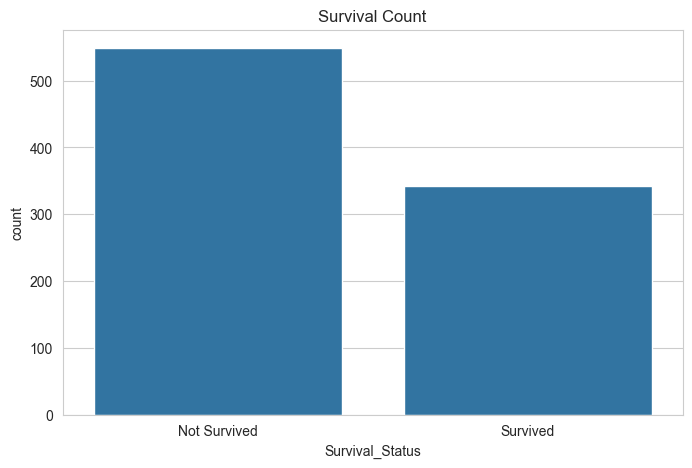

In [19]:
# Survival Count
sns.countplot(x='Survival_Status',data=train_df)
plt.title('Survival Count')
plt.show()

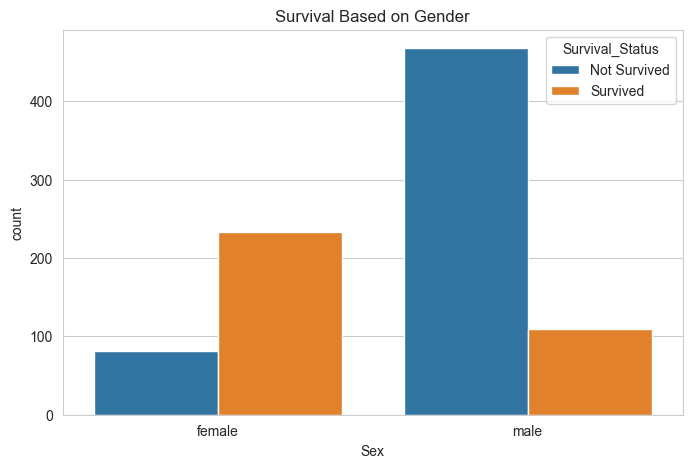

In [20]:
# Survival Based on Gender
sns.countplot(x='Sex',hue='Survival_Status',data=train_df)
plt.title('Survival Based on Gender')
plt.show()

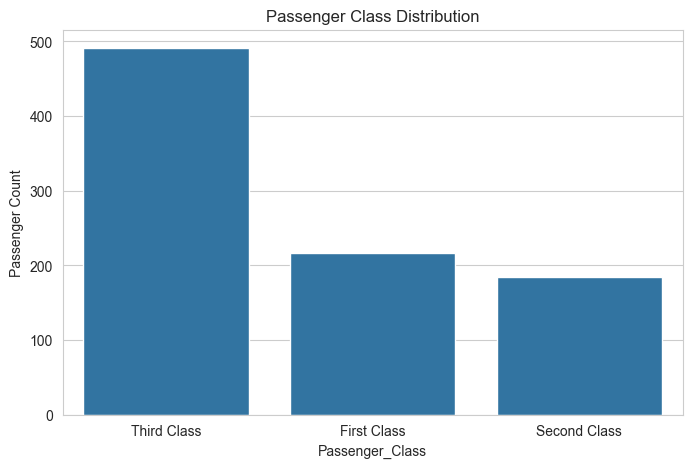

In [21]:
# Passenger Class Distribution
sns.countplot(x='Passenger_Class',data=train_df)
plt.title('Passenger Class Distribution')
plt.ylabel('Passenger Count')
plt.show()

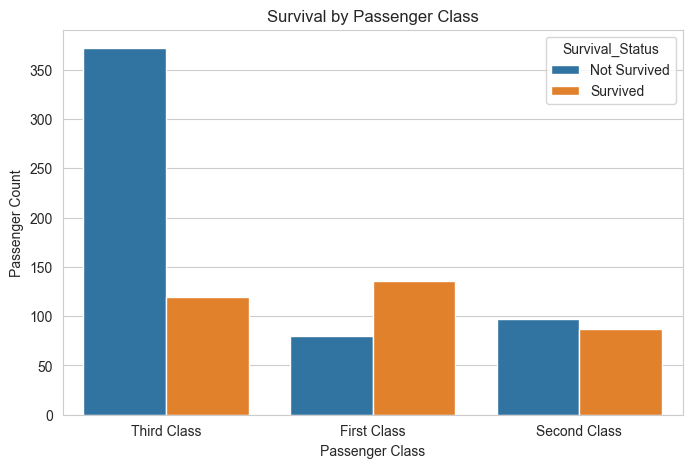

In [22]:
# Survival Based on Passenger Class
sns.countplot(x='Passenger_Class', hue='Survival_Status', data=train_df)
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Passenger Count')
plt.show()

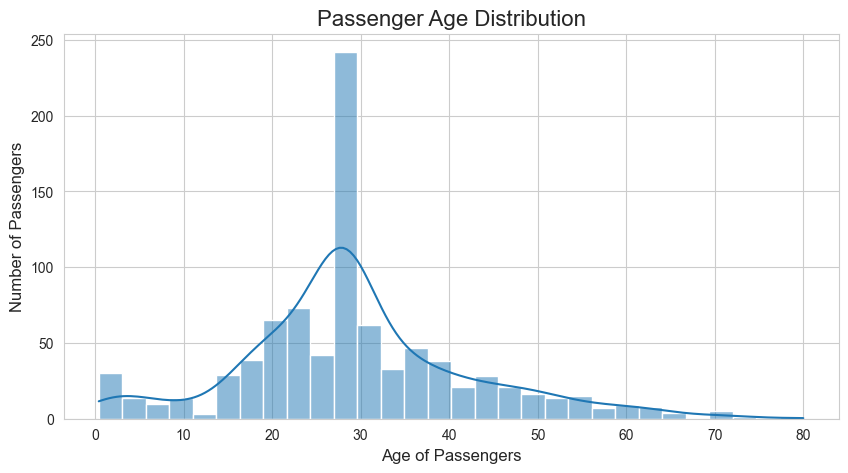

In [23]:
# Age Distribution
plt.figure(figsize=(10,5))
sns.histplot(train_df['Age'],bins=30,kde=True)
plt.title('Passenger Age Distribution',fontsize=16)
plt.xlabel('Age of Passengers',fontsize=12)
plt.ylabel('Number of Passengers',fontsize=12)
plt.show()

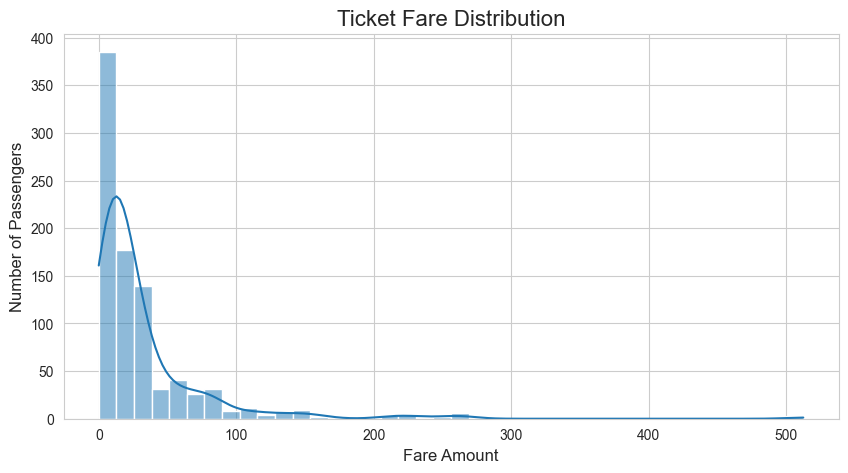

In [24]:
# Fare Distribution
plt.figure(figsize=(10,5))
sns.histplot(train_df['Fare'],bins=40,kde=True)
plt.title('Ticket Fare Distribution',fontsize=16)
plt.xlabel('Fare Amount',fontsize=12)
plt.ylabel('Number of Passengers',fontsize=12)
plt.show()

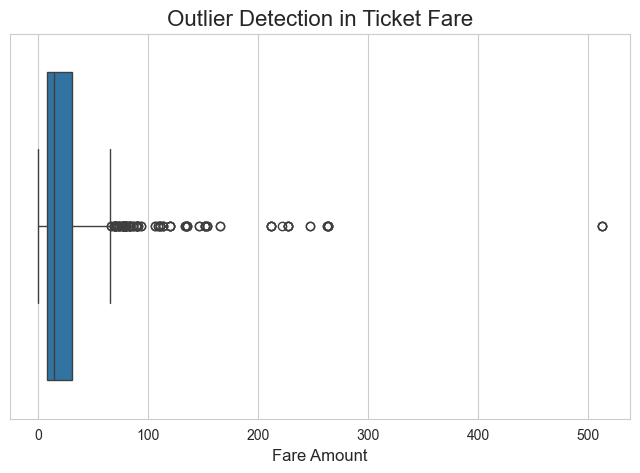

In [25]:
# Outlier Detection
plt.figure(figsize=(8,5))
sns.boxplot(x=train_df['Fare'])
plt.title('Outlier Detection in Ticket Fare',fontsize=16)
plt.xlabel('Fare Amount',fontsize=12)
plt.show()

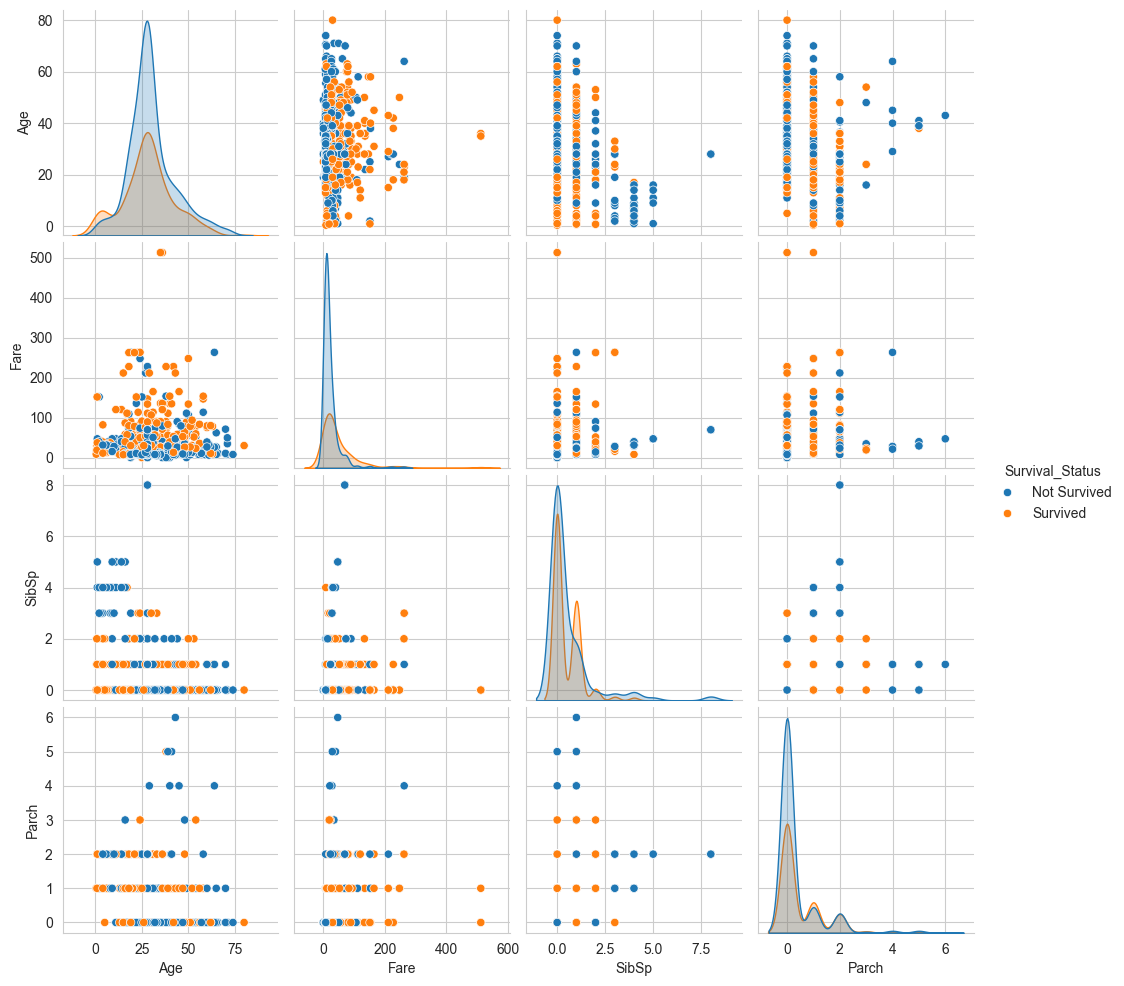

In [26]:
# Pairplot for Feature Relationships
sns.pairplot(train_df[['Age', 'Fare', 'SibSp', 'Parch', 'Survival_Status']], hue='Survival_Status',height=2.5)
plt.show()

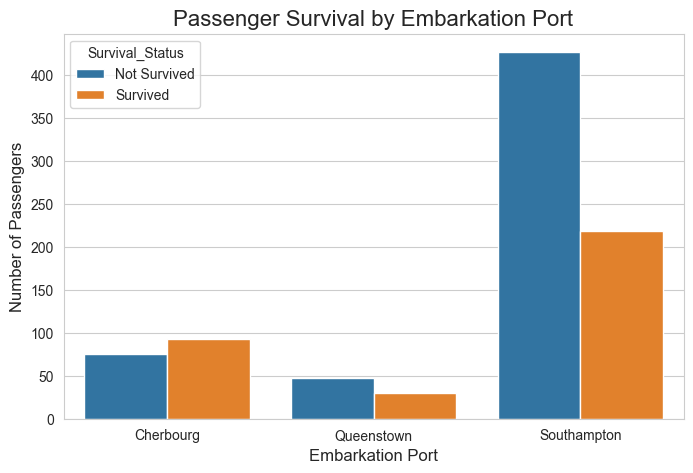

In [27]:
# Survival Based on Embarked Location
sns.countplot(x='Embarkation_Port', hue='Survival_Status', data=train_df)
plt.title('Passenger Survival by Embarkation Port',fontsize=16)
plt.xlabel('Embarkation Port',fontsize=12)
plt.ylabel('Number of Passengers',fontsize=12)
plt.show()

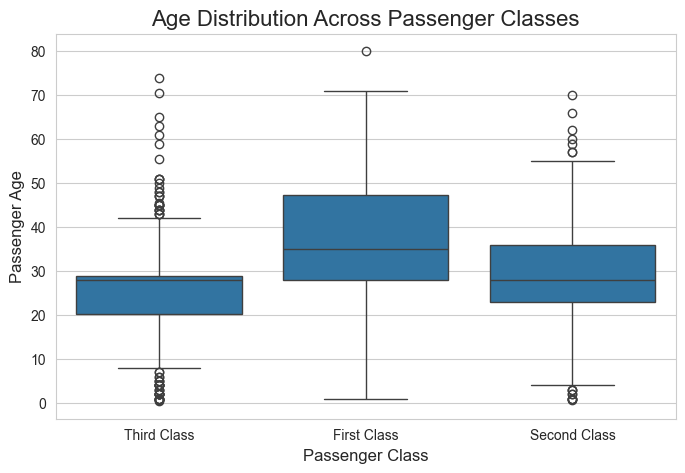

In [28]:
# Boxplot for Age and Passenger Class
plt.figure(figsize=(8,5))
sns.boxplot(x='Passenger_Class', y='Age', data=train_df)
plt.title('Age Distribution Across Passenger Classes',fontsize=16)
plt.xlabel('Passenger Class',fontsize=12)
plt.ylabel('Passenger Age',fontsize=12)
plt.show()

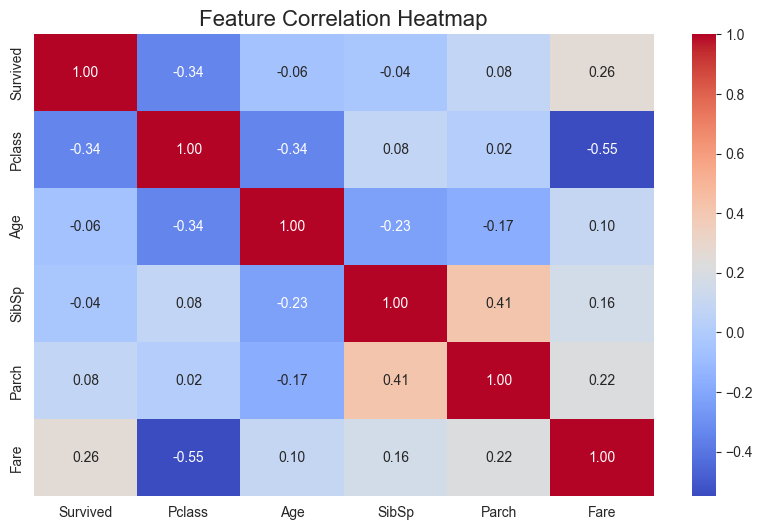

In [29]:
plt.figure(figsize=(10,6))

correlation_columns = [
    'Survived',
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare'
]

sns.heatmap(
    train_df[correlation_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Feature Correlation Heatmap',fontsize=16)
plt.show()

## Feature Relationships

In [30]:
# Survival Rate by Gender
survival_gender = train_df.groupby('Sex',observed=True)['Survived'].mean()
survival_gender

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [31]:
# Survival Rate by Passenger Class
survival_pclass = train_df.groupby('Pclass')['Survived'].mean()
survival_pclass

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

## Save Cleaned Dataset

In [32]:
train_df.to_csv('cleaned_titanic_dataset.csv', index=False)